# Utilizing Rule-Based Semantic Extraction and Text Parsing to Automate Scoring Cards in *Magic: The Gathering*
### IMT 575 - Spring 2026

In [1]:
import pandas as pd
import numpy as np

from mtg_parser.utils.paths import RAW_DIR, PROCESSED_DIR
from mtg_parser.data.extract_creatures import build_creatures_dataset
from mtg_parser.data.build_dataset import save_cleaned_dataset

%load_ext autoreload
%autoreload 2

Preprocessing stuff for our dataset

In [2]:
# Build creatures dataset from default-cards
build_creatures_dataset()

# Save the cleaned dataset
save_cleaned_dataset()

[pipeline] Default-cards dataset already exists.
[pipeline] Creatures dataset already exists.
[cleaning] Missing oracle_id rows: 0
[cleaning] Duplicate values in rows: 0
[builder] Saved combined_points_cleaned.csv to /data/processed/


## Parser vs NLP Baselines

The goal is to compare our symbolic parsing pipeline against two general NLP baselines: TF-IDF and Universal Sentence Encoder embeddings. The hand-scored `points` column includes power/toughness, keyword value, and oracle-text effects, so we subtract the power/toughness component before modeling.

This gives us `points_minus_pt`, a target that focuses the comparison on the mechanics expressed in card text and keywords.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)


from mtg_parser.utils.text_preprocessing import preprocess_oracle_text
from mtg_parser.parsing.keyword_router import parse_keywords_column
from mtg_parser.pipeline.orchestrator import build_card_ability_bundle
from mtg_parser.features.card_features import build_card_features
from mtg_parser.scoring.card_scorer import score_card
from mtg_parser.scoring.pt_scorer import score_pt

cards_df = pd.read_csv(PROCESSED_DIR / "combined_points_cleaned.csv")
cards_df["oracle_text"] = cards_df["oracle_text"].fillna("")
cards_df = parse_keywords_column(cards_df)

cards_df["oracle_text_preprocessed"] = cards_df["oracle_text"].map(preprocess_oracle_text)
cards_df["pt_score"] = cards_df.apply(
    lambda row: score_pt(row["power_numeric"], row["toughness_numeric"]),
    axis=1,
)
cards_df["points_minus_pt"] = cards_df["points"] - cards_df["pt_score"]

cards_df[["name", "points", "pt_score", "points_minus_pt", "oracle_text_preprocessed"]].head()

,name,points,pt_score,points_minus_pt,oracle_text_preprocessed
0,Benalish Hero,3,2.0,1.0,Banding
1,Merfolk of the Pearl Trident,2,2.0,0.0,
2,Goblin Balloon Brigade,3,2.0,1.0,{R}: This creature gains flying until end of t...
3,Birds of Paradise,4,1.0,3.0,Flying\n{T}: Add one mana of any color.
4,Will-o'-the-Wisp,3,1.0,2.0,Flying \n{B}: Regenerate this creature.


### Rule-Based Parser Scores

Our pipeline splits oracle text into ability blocks, classifies those abilities, extracts mechanics features, and applies our scoring weights. To compare against the NLP baselines, we evaluate the parser's mechanics score only: ability score plus keyword score.

In [4]:
parser_rows = []

for idx, row in cards_df.iterrows():
    bundle = build_card_ability_bundle(row)
    card_features = build_card_features(bundle, row)
    score = score_card(card_features)

    parser_rows.append({
        "idx": idx,
        "oracle_id": row["oracle_id"],
        "name": row["name"],
        "set": row["set"],
        "manual_points": row["points"],
        "points_minus_pt": row["points_minus_pt"],
        "parser_ability_score": score.ability,
        "parser_keyword_score": score.keyword,
        "parser_pt_score": score.pt,
        "parser_mechanics_score": score.ability + score.keyword,
        "parser_total_score": score.total,
        "parser_mechanics_residual": row["points_minus_pt"] - (score.ability + score.keyword),
        "parser_total_residual": row["points"] - score.total,
    })

parser_df = pd.DataFrame(parser_rows).set_index("idx")

parser_df.head()

,oracle_id,name,set,manual_points,points_minus_pt,parser_ability_score,parser_keyword_score,parser_pt_score,parser_mechanics_score,parser_total_score,parser_mechanics_residual,parser_total_residual
idx,,,,,,,,,,,,
0,4c81cfb7-8765-4e28-ae33-4287fa9a86cc,Benalish Hero,lea,3,1.0,0,1,2.0,1,3.0,0.0,0.0
1,218d9277-c179-4de3-9c7f-79b5a6d4fa38,Merfolk of the Pearl Trident,lea,2,0.0,0,0,2.0,0,2.0,0.0,0.0
2,10bc98b0-3fdc-46d1-8d3b-6d160e9dd62f,Goblin Balloon Brigade,lea,3,1.0,1,0,2.0,1,3.0,0.0,0.0
3,d3a0b660-358c-41bd-9cd2-41fbf3491b1a,Birds of Paradise,lea,4,3.0,2,1,1.0,3,4.0,0.0,0.0
4,8b60fcfe-fb90-4a00-a708-25b59bfc9b5a,Will-o'-the-Wisp,lea,3,2.0,1,1,1.0,2,3.0,0.0,0.0


### Shared Train/Test Split

The NLP models use an 80/20 train/test split. The parser is rule-based and does not train, but we evaluate it on the same test rows so all reported metrics are directly comparable.

In [5]:
train_idx, test_idx = train_test_split(
    cards_df.index,
    test_size=0.2,
    random_state=42,
)

train_df = cards_df.loc[train_idx]
test_df = cards_df.loc[test_idx]

y_train = train_df["points_minus_pt"]
y_test = test_df["points_minus_pt"]

len(train_df), len(test_df)

(685, 172)

### TF-IDF Baseline

The TF-IDF baseline represents oracle text with word and phrase frequency features, then uses Ridge regression to predict `points_minus_pt`. This tests how far a lightweight text model can get without explicit Magic rules or mechanic-specific parsing.

In [6]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(train_df["oracle_text_preprocessed"])
X_test_tfidf = tfidf.transform(test_df["oracle_text_preprocessed"])

tfidf_model = Ridge(alpha=1.0)
tfidf_model.fit(X_train_tfidf, y_train)

tfidf_preds = tfidf_model.predict(X_test_tfidf)

tfidf_results = test_df[["oracle_id", "name", "set", "points_minus_pt"]].copy()
tfidf_results["tfidf_pred"] = tfidf_preds
tfidf_results["tfidf_residual"] = tfidf_results["points_minus_pt"] - tfidf_results["tfidf_pred"]

tfidf_results.head()

,oracle_id,name,set,points_minus_pt,tfidf_pred,tfidf_residual
712,33f4fcd5-4eea-4146-a564-da5511a8ee0a,Thought Shucker,blb,3.0,2.714143,0.285857
603,b2b76070-f103-4f83-ad21-119e6352f2cd,Glowstone Recluse,iko,4.0,3.259793,0.740207
120,b373e978-c58b-465a-b68a-9d4acec9dce0,Dwarven Blastminer,ons,3.0,2.170205,0.829795
208,17191fa9-e956-4f46-b541-465790125b6b,Hystrodon,ons,4.0,3.006959,0.993041
380,3f15349a-6ac6-4091-95a3-ae9f593e4650,Surgespanner,lrw,2.0,1.922808,0.077192


### Universal Sentence Encoder Baseline

The embedding baseline uses Universal Sentence Encoder, matching the embedding-style approach discussed for the presentation comparison. Each card's oracle text is converted into a dense vector, then Ridge regression predicts `points_minus_pt` from those vectors.

In [7]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API.*")

import tensorflow_hub as hub

embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4", options=None)

X_train_embed = np.asarray(embed(train_df["oracle_text_preprocessed"].tolist()))
X_test_embed = np.asarray(embed(test_df["oracle_text_preprocessed"].tolist()))

embedding_model = Ridge(alpha=1.0)
embedding_model.fit(X_train_embed, y_train)

embedding_preds = embedding_model.predict(X_test_embed)

embedding_results = test_df[["oracle_id", "name", "set", "points_minus_pt"]].copy()
embedding_results["embedding_pred"] = embedding_preds
embedding_results["embedding_residual"] = (
    embedding_results["points_minus_pt"] - embedding_results["embedding_pred"]
)

embedding_results.head()

,oracle_id,name,set,points_minus_pt,embedding_pred,embedding_residual
712,33f4fcd5-4eea-4146-a564-da5511a8ee0a,Thought Shucker,blb,3.0,3.139592,-0.139592
603,b2b76070-f103-4f83-ad21-119e6352f2cd,Glowstone Recluse,iko,4.0,3.216335,0.783665
120,b373e978-c58b-465a-b68a-9d4acec9dce0,Dwarven Blastminer,ons,3.0,2.729125,0.270875
208,17191fa9-e956-4f46-b541-465790125b6b,Hystrodon,ons,4.0,3.983907,0.016093
380,3f15349a-6ac6-4091-95a3-ae9f593e4650,Surgespanner,lrw,2.0,1.177712,0.822288


### Model Performance

We compare the parser, TF-IDF, and embedding model using MAE, RMSE, and R² on the same test rows. Lower MAE and RMSE mean smaller prediction errors, while higher R² means the model explains more variance in the target score.

In [8]:
parser_test = parser_df.loc[test_idx]

metrics_df = pd.DataFrame([
    {
        "model": "parser_mechanics",
        "mae": mean_absolute_error(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
        "rmse": root_mean_squared_error(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
        "r2": r2_score(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
    },
    {
        "model": "tfidf_ridge",
        "mae": mean_absolute_error(y_test, tfidf_preds),
        "rmse": root_mean_squared_error(y_test, tfidf_preds),
        "r2": r2_score(y_test, tfidf_preds),
    },
    {
        "model": "embedding_use_ridge",
        "mae": mean_absolute_error(y_test, embedding_preds),
        "rmse": root_mean_squared_error(y_test, embedding_preds),
        "r2": r2_score(y_test, embedding_preds),
    },
])

metrics_df

,model,mae,rmse,r2
0,parser_mechanics,0.308140,0.585682,0.865540
1,tfidf_ridge,0.860521,1.105145,0.521249
2,embedding_use_ridge,0.789474,1.057294,0.561810


### Performance Comparison

The rule-based parser has lower error and higher R² than both NLP baselines. This supports the main presentation claim: *Magic* oracle text is semi-structured and rules-heavy, so domain-specific parsing captures information that generic text models miss.

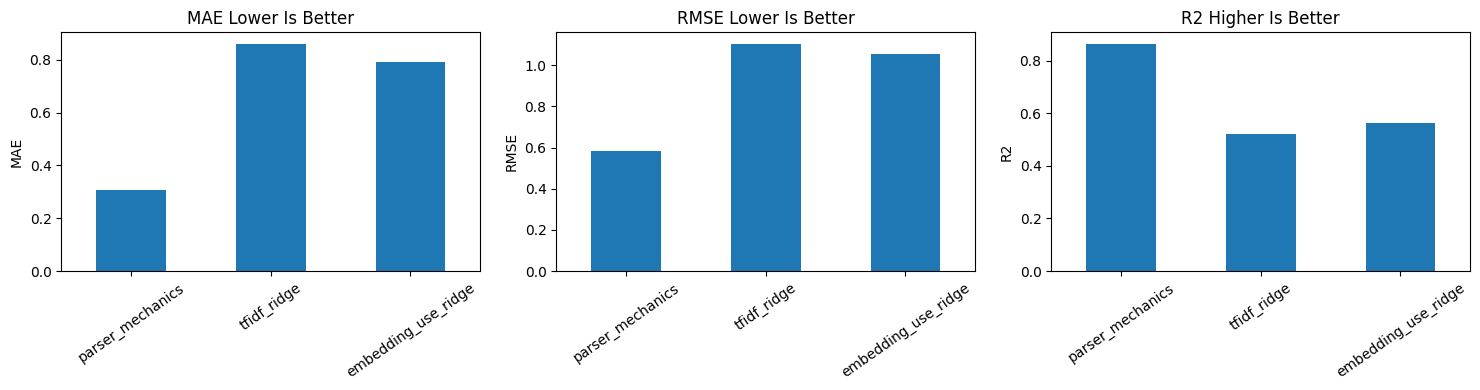

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_df.plot(kind="bar", x="model", y="mae", ax=axes[0], legend=False)
axes[0].set_title("MAE Lower Is Better")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE")

metrics_df.plot(kind="bar", x="model", y="rmse", ax=axes[1], legend=False)
axes[1].set_title("RMSE Lower Is Better")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")

metrics_df.plot(kind="bar", x="model", y="r2", ax=axes[2], legend=False)
axes[2].set_title("R2 Higher Is Better")
axes[2].set_xlabel("")
axes[2].set_ylabel("R2")

for ax in axes:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

### Residual Analysis

Residuals show where each approach over- or under-predicts `points_minus_pt`. A tighter distribution around zero indicates more consistent predictions, while wider residuals suggest mechanics or card patterns the model is not capturing well.

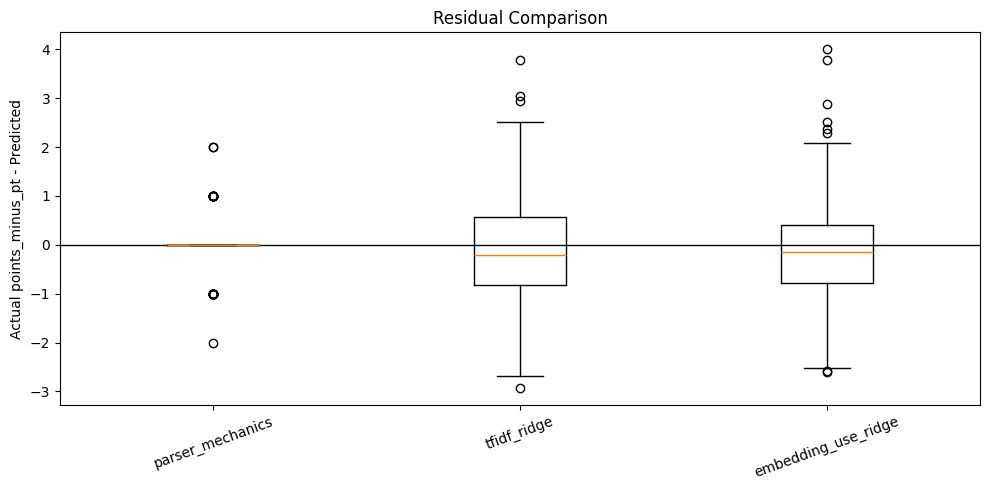

In [10]:
residuals_df = pd.DataFrame({
    "parser_mechanics": parser_test["parser_mechanics_residual"].values,
    "tfidf_ridge": tfidf_results["tfidf_residual"].values,
    "embedding_use_ridge": embedding_results["embedding_residual"].values,
})

plt.figure(figsize=(10, 5))
plt.boxplot(
    [residuals_df[col] for col in residuals_df.columns],
    tick_labels=residuals_df.columns,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Residual Comparison")
plt.ylabel("Actual points_minus_pt - Predicted")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Actual vs Predicted Scores

These plots compare each model's predictions against the true `points_minus_pt` values. Points closer to the diagonal line are better predictions; points far from the line show cases where a model disagrees with the hand-scored labels.

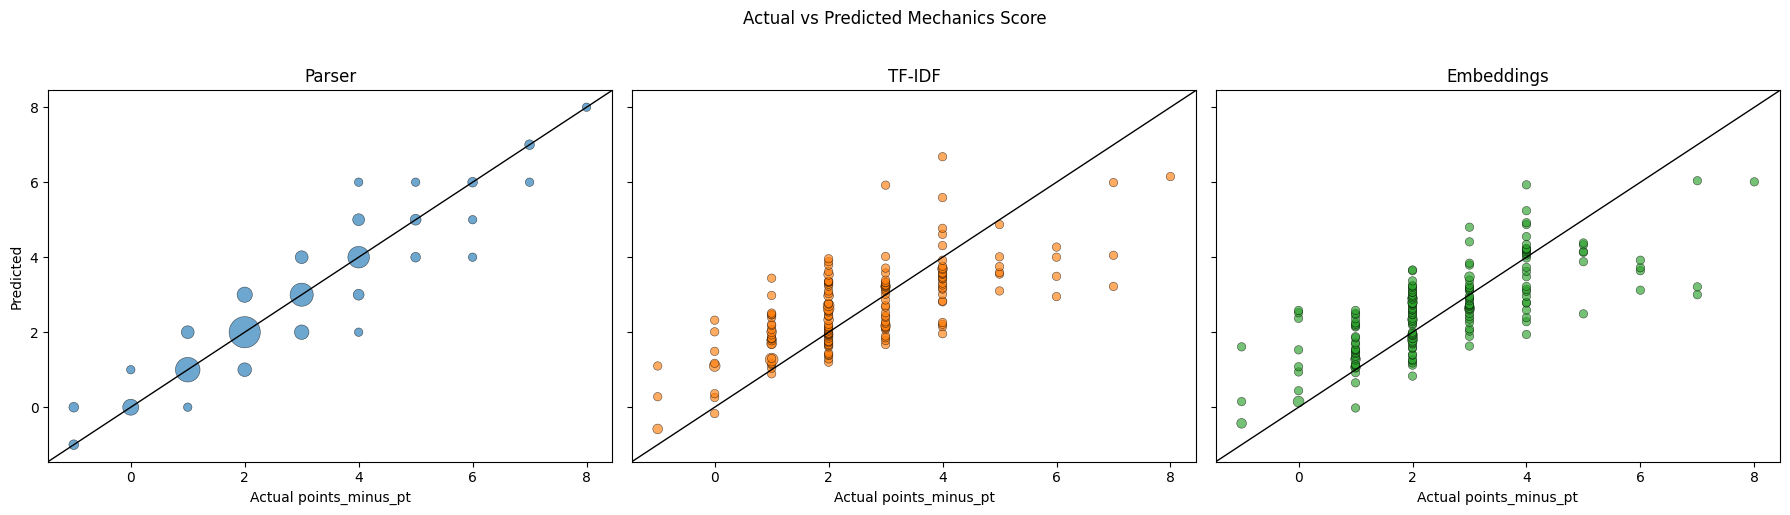

In [11]:
actual = test_df["points_minus_pt"]

model_plots = [
    ("Parser", parser_test["parser_mechanics_score"], "tab:blue"),
    ("TF-IDF", tfidf_preds, "tab:orange"),
    ("Embeddings", embedding_preds, "tab:green"),
]

min_val = min(
    actual.min(),
    parser_test["parser_mechanics_score"].min(),
    tfidf_preds.min(),
    embedding_preds.min(),
)
max_val = max(
    actual.max(),
    parser_test["parser_mechanics_score"].max(),
    tfidf_preds.max(),
    embedding_preds.max(),
)

padding = (max_val - min_val) * 0.05
axis_min = min_val - padding
axis_max = max_val + padding

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, (title, preds, color) in zip(axes, model_plots):
    plot_df = pd.DataFrame({
        "actual": actual.values,
        "predicted": np.asarray(preds),
    })

    # Keep continuous model predictions visually readable while still showing overlap.
    if title != "Parser":
        plot_df["predicted"] = plot_df["predicted"].round(2)

    counts = (
        plot_df
        .groupby(["actual", "predicted"])
        .size()
        .reset_index(name="count")
    )

    ax.scatter(
        counts["actual"],
        counts["predicted"],
        s=25 + counts["count"] * 12,
        alpha=0.65,
        color=color,
        edgecolor="black",
        linewidth=0.4,
    )

    ax.plot([axis_min, axis_max], [axis_min, axis_max], color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Actual points_minus_pt")
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

axes[0].set_ylabel("Predicted")
fig.suptitle("Actual vs Predicted Mechanics Score", y=1.02)
plt.tight_layout()
plt.show()

Marker size indicates how many cards share the same actual/predicted coordinate. This matters most for the parser because its rule-based scores are discrete, so many cards overlap exactly. The NLP baselines produce continuous predictions, which spread points across more unique coordinates.

### Largest Parser Misses

Even the parser's worst cases are small. On the held-out test set no creature is off by more than **2 points**, and most of the largest residuals miss by just 1 — consistent with the overall MAE of ~0.31. The misses also split between slight over- and under-valuations, so there is no systematic directional bias; these are edge cases, not pipeline failures.

The residuals that remain point to context the rule-based features don't yet capture. The handful of 2-point misses run in both directions — the parser overvalues a card like *Arcanis the Omnipotent* and undervalues one like *Clement, the Worrywort* — which likely reflects abilities whose practical value depends on board state, synergy, or text patterns not yet represented in the feature rules. We treat these as a targeted to-do list for future scoring refinements rather than evidence of a broken system.


In [12]:
parser_test.assign(
    abs_residual=parser_test["parser_mechanics_residual"].abs()
).sort_values("abs_residual", ascending=False)[
    [
        "name",
        "set",
        "points_minus_pt",
        "parser_mechanics_score",
        "parser_mechanics_residual",
    ]
].head(10)

,name,set,points_minus_pt,parser_mechanics_score,parser_mechanics_residual
247,Arcanis the Omnipotent,ons,4.0,6,-2.0
784,"Clement, the Worrywort",blb,6.0,4,2.0
673,Adaptive Shimmerer,iko,4.0,2,2.0
791,Thought-Stalker Warlock,blb,3.0,2,1.0
360,Dauntless Dourbark,lrw,0.0,1,-1.0
213,Riptide Chronologist,ons,1.0,2,-1.0
544,Thousand Winds,ktk,4.0,5,-1.0
760,Cindering Cutthroat,blb,3.0,2,1.0
212,Fallen Cleric,ons,3.0,4,-1.0
290,Warren-Scourge Elf,lrw,2.0,3,-1.0


### Summary

On this dataset, the parser outperforms both TF-IDF and Universal Sentence Encoder baselines. This supports using a rule-based mechanics parser for *Magic: The Gathering* card text: the language is templated, semi-structured, and tightly tied to formal game rules. The remaining high-residual cases give us concrete directions for future feature and scoring improvements.

## Power Creep Over Time

The sections above score each creature and compare the parser against NLP baselines on a per-card basis. Here we reuse that same parser output to ask a different question: **how have creature power scores changed across *Magic*'s history?**

We attach each scored creature's set release year (already carried in the cleaned data as `year`) to `parser_df`, then average the parser's total and component scores by year. The hand-scored `points` are included as an external check that the parser's trend matches human judgment.

> All values below are recomputed live from the current parser, so they will differ slightly from the figures in the original slide deck. The shape of the trend is what matters.


In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# parser_df is indexed by the original cards_df row index, so the year join is a lookup.
parser_df["year"] = cards_df.loc[parser_df.index, "year"].astype(int)

# Average the parser + hand scores per release year.
yearly = parser_df.groupby("year", as_index=False).agg(
    n_cards=("oracle_id", "count"),
    total=("parser_total_score", "mean"),
    pt=("parser_pt_score", "mean"),
    keyword=("parser_keyword_score", "mean"),
    ability=("parser_ability_score", "mean"),
    mechanics=("parser_mechanics_score", "mean"),
    manual=("manual_points", "mean"),
)

first_year, last_year = int(yearly["year"].min()), int(yearly["year"].max())


def fit_curve(x, y, degree=3, n=200):
    """Degree-3 polynomial trend, matching the original power-creep analysis."""
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    model.fit(x.reshape(-1, 1), y)
    grid = np.linspace(x.min(), x.max(), n)
    return grid, model.predict(grid.reshape(-1, 1))


def year_delta(col):
    a = yearly.loc[yearly["year"] == first_year, col].iloc[0]
    b = yearly.loc[yearly["year"] == last_year, col].iloc[0]
    return a, b, b - a


component_colors = {
    "total": "#1f77b4",
    "manual": "#6f6f6f",
    "pt": "#4c78a8",
    "keyword": "#f58518",
    "ability": "#54a24b",
}

yearly.round(2)


,year,n_cards,total,pt,keyword,ability,mechanics,manual
0,1993,92,6.87,5.66,0.35,0.86,1.21,6.76
1,2002,174,7.88,5.66,0.67,1.56,2.22,7.87
2,2007,169,8.07,5.47,0.76,1.84,2.60,7.94
3,2014,121,9.03,6.43,1.01,1.60,2.60,9.03
4,2020,138,9.79,6.74,0.99,2.07,3.05,9.79
5,2024,163,9.02,5.68,1.18,2.16,3.34,9.15


### Average parser power score over time

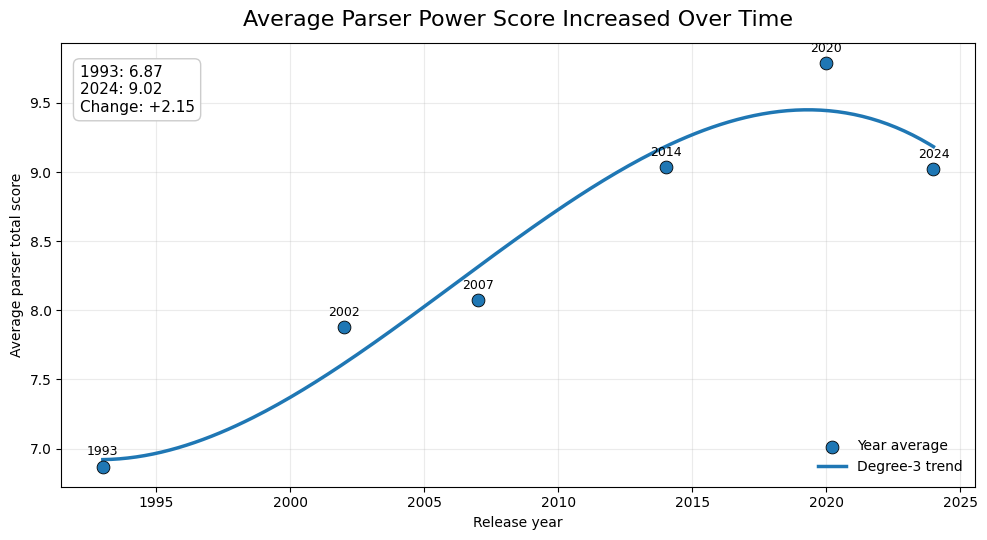

In [14]:
x = yearly["year"].to_numpy()
y = yearly["total"].to_numpy()
grid, pred = fit_curve(x, y)
first_val, last_val, change = year_delta("total")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(x, y, s=85, color=component_colors["total"], edgecolor="black",
           linewidth=0.6, label="Year average", zorder=3)
ax.plot(grid, pred, color=component_colors["total"], linewidth=2.5, label="Degree-3 trend")
for _, r in yearly.iterrows():
    ax.annotate(str(int(r["year"])), (r["year"], r["total"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

ax.set_title("Average Parser Power Score Increased Over Time", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average parser total score")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
ax.text(0.02, 0.95,
        f"{first_year}: {first_val:.2f}\n{last_year}: {last_val:.2f}\nChange: {change:+.2f}",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.4"))
fig.tight_layout()
plt.show()


### Power creep by component

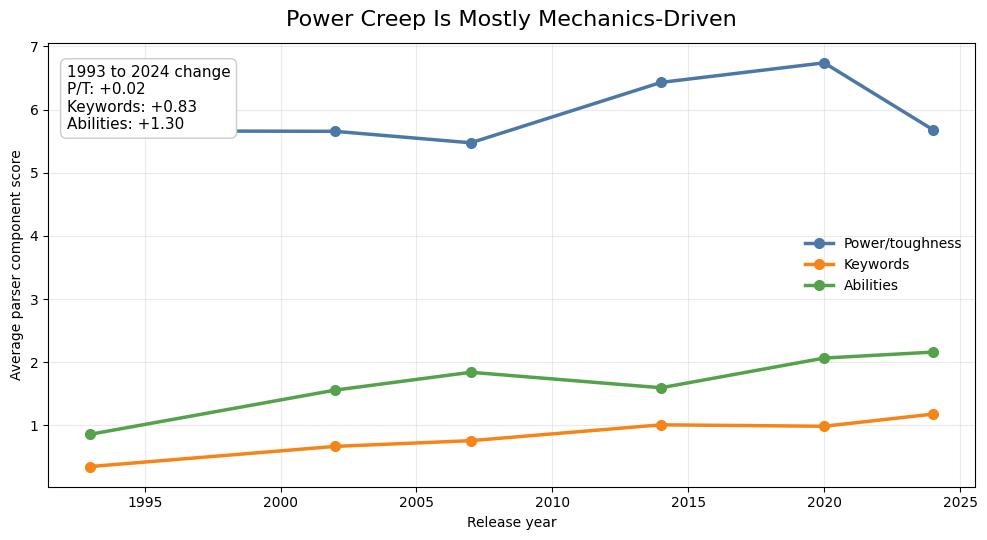

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for col, label in [("pt", "Power/toughness"), ("keyword", "Keywords"), ("ability", "Abilities")]:
    ax.plot(yearly["year"], yearly[col], marker="o", linewidth=2.5, markersize=7,
            color=component_colors[col], label=label)

d_pt = year_delta("pt")[2]
d_kw = year_delta("keyword")[2]
d_ab = year_delta("ability")[2]

ax.set_title("Power Creep Is Mostly Mechanics-Driven", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average parser component score")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
ax.text(0.02, 0.95,
        f"{first_year} to {last_year} change\nP/T: {d_pt:+.2f}\n"
        f"Keywords: {d_kw:+.2f}\nAbilities: {d_ab:+.2f}",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.4"))
fig.tight_layout()
plt.show()


### Component composition by year

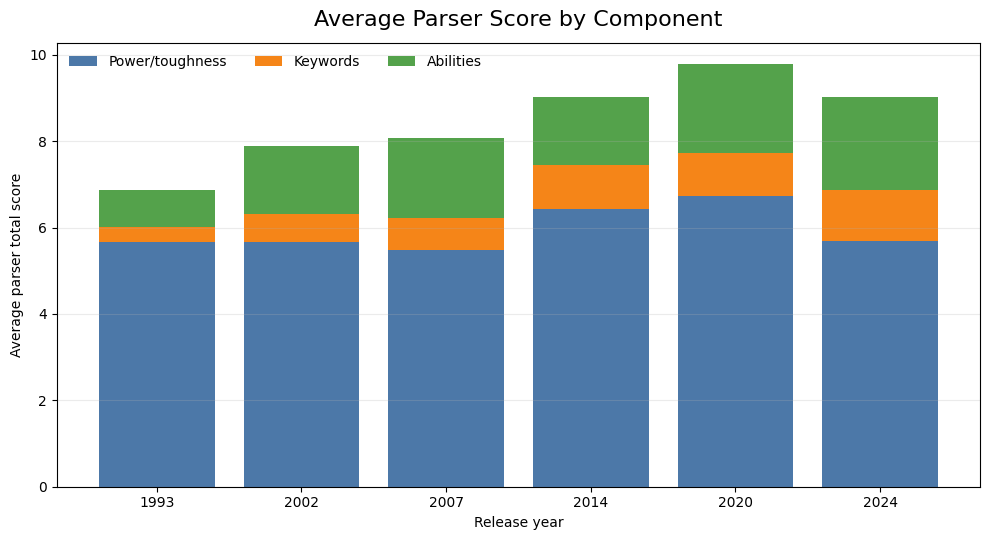

In [16]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(yearly))
for col, label in [("pt", "Power/toughness"), ("keyword", "Keywords"), ("ability", "Abilities")]:
    ax.bar(yearly["year"].astype(str), yearly[col], bottom=bottom,
           color=component_colors[col], label=label)
    bottom += yearly[col].to_numpy()

ax.set_title("Average Parser Score by Component", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average parser total score")
ax.legend(frameon=False, ncols=3, loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


### Parser trend vs hand-scored trend

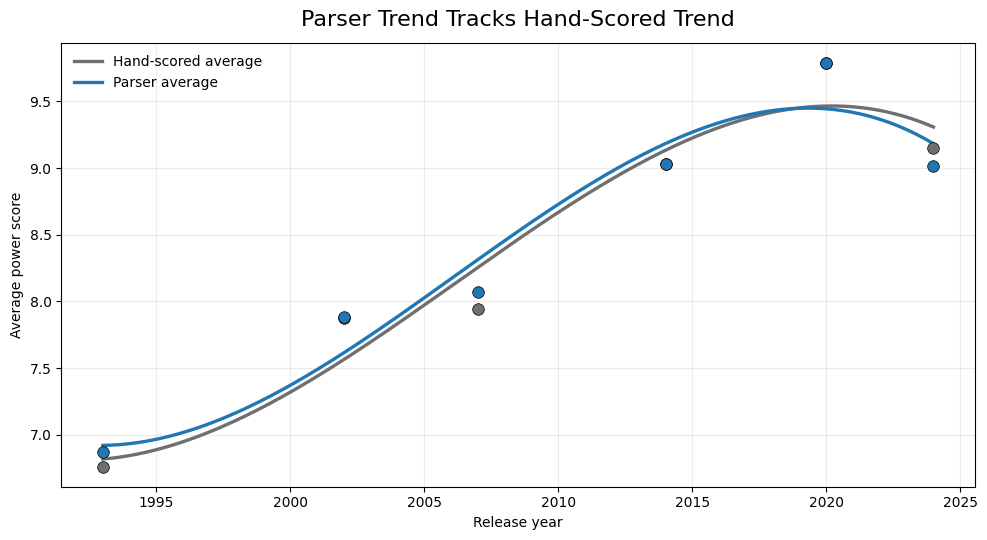

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for col, label in [("manual", "Hand-scored average"), ("total", "Parser average")]:
    grid, pred = fit_curve(x, yearly[col].to_numpy())
    ax.scatter(yearly["year"], yearly[col], s=70, color=component_colors[col],
               edgecolor="black", linewidth=0.5, zorder=3)
    ax.plot(grid, pred, linewidth=2.4, color=component_colors[col], label=label)

ax.set_title("Parser Trend Tracks Hand-Scored Trend", fontsize=16, pad=12)
ax.set_xlabel("Release year")
ax.set_ylabel("Average power score")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Reading the trend.** Average parser power rises from the game's earliest sets through the 2010s before flattening in the most recent years — the same arc the hand scores show, which is reassuring evidence that the rule-based parser tracks real design change rather than a scoring artifact. Decomposing the score shows the increase is **mechanics-driven**: raw power/toughness is nearly flat across three decades, while the *abilities* and *keywords* components account for almost all of the growth. Newer creatures aren't bigger so much as they *do more*.
